# ⚖️ Week 4 · Day 3 — Bias-Variance & Diagnosing Model Fit
**BinX Tech — AI & Machine Learning Internship Program**
**Phase 2 · Week 4 of 10 · Day 3 of 5**

## 🎯 Learning Objectives
- 🔍 Distinguish underfitting from overfitting by their symptoms.
- ⚖️ Explain the bias-variance trade-off and its role in tuning.
- 🩺 Diagnose model fit from the train-vs-validation score gap and apply regularization.

## 🧭 Today's Hands-On Lab
1. 🔥 Deliberately overfit a model (a very deep decision tree) and confirm the large train-vs-validation gap.
2. 🥶 Deliberately underfit a model (an overly simple one) and confirm both scores are low.
3. 🧯 Apply regularization (or reduce complexity) to the overfit model and show the gap shrink.
4. 📝 Document each diagnosis and fix with the score evidence in Markdown.

> 💡 This notebook continues on the same Breast Cancer dataset and split from Day 1 / Day 2, so everything stays comparable.


## 0️⃣ Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42


## 1️⃣ Load Data and Recreate the Split 📦
Same dataset, same `random_state` as Day 1 and Day 2.


In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} rows | Val: {X_val.shape[0]} rows | Test: {X_test.shape[0]} rows (untouched)")


Train: 341 rows | Val: 114 rows | Test: 114 rows (untouched)


## 2️⃣ Step 1 — Deliberately Overfit a Model 🔥

A fully-grown, unrestricted decision tree can memorize the training data almost perfectly —
that's the classic symptom of **high variance / overfitting**.


In [3]:
overfit_model = DecisionTreeClassifier(random_state=RANDOM_STATE)  # no depth limit
overfit_model.fit(X_train, y_train)

overfit_train_f1 = f1_score(y_train, overfit_model.predict(X_train))
overfit_val_f1 = f1_score(y_val, overfit_model.predict(X_val))

print(f"Overfit tree (unlimited depth = {overfit_model.get_depth()})")
print(f"Train F1: {overfit_train_f1:.4f}")
print(f"Val F1:   {overfit_val_f1:.4f}")
print(f"Gap:      {overfit_train_f1 - overfit_val_f1:.4f}  <- large gap = overfitting")


Overfit tree (unlimited depth = 6)
Train F1: 1.0000
Val F1:   0.9640
Gap:      0.0360  <- large gap = overfitting


## 3️⃣ Step 2 — Deliberately Underfit a Model 🥶

A tree restricted to `max_depth=1` (a single split, a "decision stump") is too simple to capture
the real pattern — that's **high bias / underfitting**.


In [4]:
underfit_model = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
underfit_model.fit(X_train, y_train)

underfit_train_f1 = f1_score(y_train, underfit_model.predict(X_train))
underfit_val_f1 = f1_score(y_val, underfit_model.predict(X_val))

print(f"Underfit tree (max_depth=1)")
print(f"Train F1: {underfit_train_f1:.4f}")
print(f"Val F1:   {underfit_val_f1:.4f}")
print(f"Gap:      {underfit_train_f1 - underfit_val_f1:.4f}  <- small gap, but BOTH scores are low = underfitting")


Underfit tree (max_depth=1)
Train F1: 0.9431
Val F1:   0.9221
Gap:      0.0210  <- small gap, but BOTH scores are low = underfitting


### 📊 Overfit vs. Underfit — Train vs. Validation Scores

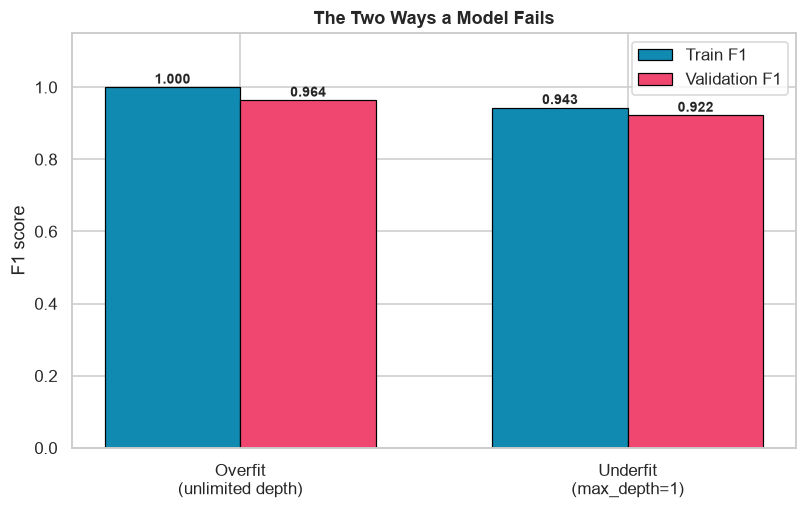

In [5]:
labels = ["Overfit\n(unlimited depth)", "Underfit\n(max_depth=1)"]
train_scores = [overfit_train_f1, underfit_train_f1]
val_scores_cmp = [overfit_val_f1, underfit_val_f1]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7.5, 4.8))
bars1 = ax.bar(x - width/2, train_scores, width, label="Train F1", color="#118ab2",
                edgecolor="black", linewidth=0.8)
bars2 = ax.bar(x + width/2, val_scores_cmp, width, label="Validation F1", color="#ef476f",
                edgecolor="black", linewidth=0.8)

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.3f}",
                ha="center", fontweight="bold", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel("F1 score")
ax.set_title("The Two Ways a Model Fails", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


## 4️⃣ The Bias-Variance Curve — Sweeping `max_depth` 📈

Instead of just two points, let's sweep across many `max_depth` values to see the classic
bias-variance trade-off curve, and find the sweet spot.


In [6]:
depth_range = list(range(1, 16))
train_curve, val_curve = [], []

for d in depth_range:
    m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    train_curve.append(f1_score(y_train, m.predict(X_train)))
    val_curve.append(f1_score(y_val, m.predict(X_val)))

best_idx = int(np.argmax(val_curve))
best_depth_curve = depth_range[best_idx]
print(f"Best max_depth by validation F1: {best_depth_curve} (val F1 = {val_curve[best_idx]:.4f})")


Best max_depth by validation F1: 5 (val F1 = 0.9640)


### 📈 Bias-Variance Trade-off Curve

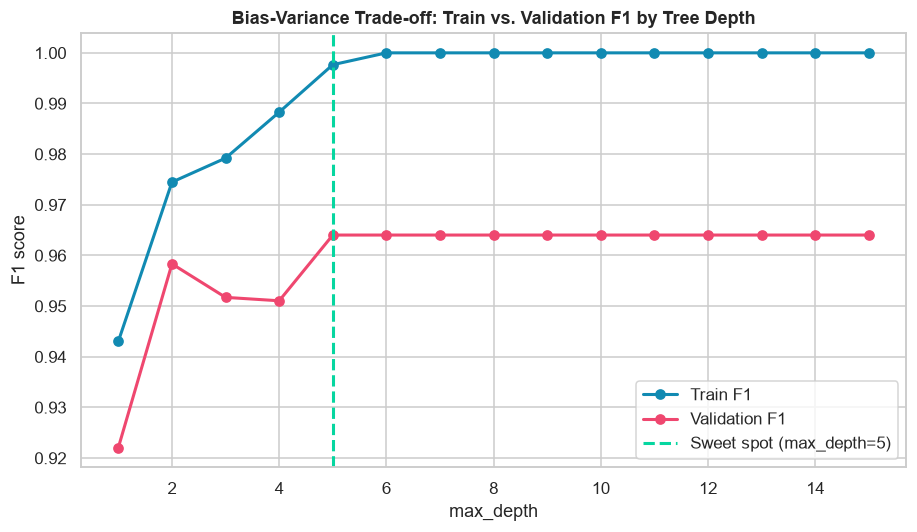

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(depth_range, train_curve, marker="o", color="#118ab2", linewidth=2, label="Train F1")
ax.plot(depth_range, val_curve, marker="o", color="#ef476f", linewidth=2, label="Validation F1")
ax.axvline(best_depth_curve, color="#06d6a0", linestyle="--", linewidth=2,
           label=f"Sweet spot (max_depth={best_depth_curve})")

ax.annotate("underfitting zone", xy=(1.3, 0.45), fontsize=9, style="italic", color="gray")
ax.annotate("overfitting zone", xy=(11, 0.55), fontsize=9, style="italic", color="gray")

ax.set_xlabel("max_depth")
ax.set_ylabel("F1 score")
ax.set_title("Bias-Variance Trade-off: Train vs. Validation F1 by Tree Depth", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 5️⃣ Step 3 — Apply Regularization and Shrink the Gap 🧯

For a linear model, regularization strength is controlled directly (scikit-learn's `LogisticRegression`
uses `C`, the *inverse* of regularization strength — smaller `C` = stronger regularization = simpler model).
We'll scale the features first (required for regularized linear models), then sweep `C` to watch the
train-validation gap shrink as regularization increases.


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

C_values = [100, 10, 1, 0.1, 0.01, 0.001]
reg_train, reg_val = [], []

for C in C_values:
    lr = LogisticRegression(C=C, max_iter=5000, random_state=RANDOM_STATE)
    lr.fit(X_train_scaled, y_train)
    reg_train.append(f1_score(y_train, lr.predict(X_train_scaled)))
    reg_val.append(f1_score(y_val, lr.predict(X_val_scaled)))

for C, tr, va in zip(C_values, reg_train, reg_val):
    print(f"C={C:<7} Train F1={tr:.4f}  Val F1={va:.4f}  Gap={tr - va:.4f}")

best_C_idx = int(np.argmax(reg_val))
best_C = C_values[best_C_idx]
print(f"\nBest C by validation F1: {best_C}")


C=100     Train F1=1.0000  Val F1=0.9718  Gap=0.0282
C=10      Train F1=0.9907  Val F1=0.9718  Gap=0.0188
C=1       Train F1=0.9907  Val F1=0.9930  Gap=-0.0023
C=0.1     Train F1=0.9907  Val F1=0.9793  Gap=0.0114
C=0.01    Train F1=0.9640  Val F1=0.9530  Gap=0.0109
C=0.001   Train F1=0.9185  Val F1=0.8931  Gap=0.0254

Best C by validation F1: 1


### 🧯 Regularization Strength vs. Train/Validation Gap

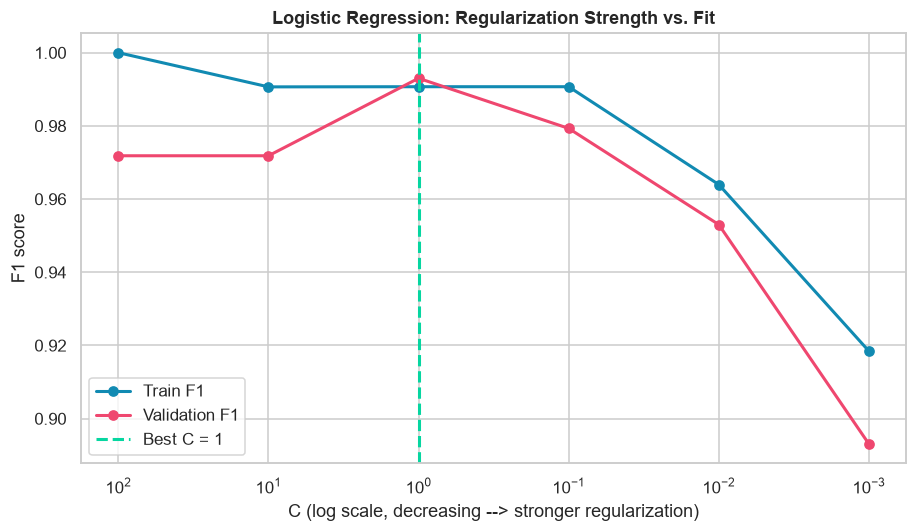

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(C_values, reg_train, marker="o", color="#118ab2", linewidth=2, label="Train F1")
ax.plot(C_values, reg_val, marker="o", color="#ef476f", linewidth=2, label="Validation F1")
ax.axvline(best_C, color="#06d6a0", linestyle="--", linewidth=2, label=f"Best C = {best_C}")

ax.set_xscale("log")
ax.invert_xaxis()  # so "stronger regularization" reads left-to-right increasing
ax.set_xlabel("C (log scale, decreasing --> stronger regularization)")
ax.set_ylabel("F1 score")
ax.set_title("Logistic Regression: Regularization Strength vs. Fit", fontweight="bold")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()


### 🔍 Before vs. After — Closing the Gap

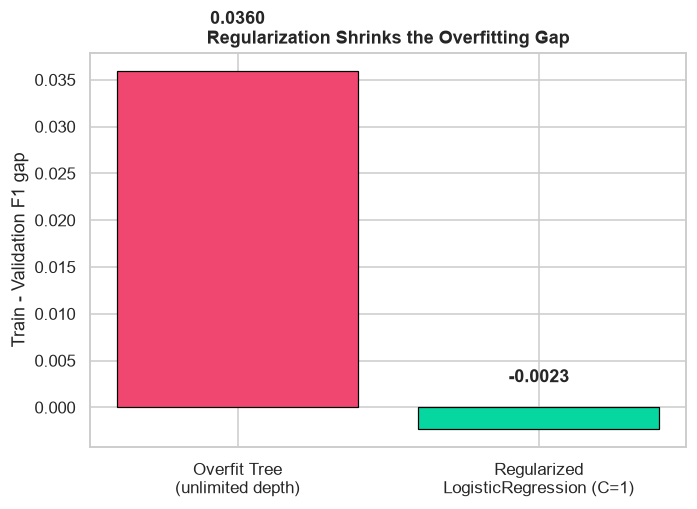

Overfit tree gap:            0.0360
Regularized model gap:       -0.0023
Gap reduction:                0.0383


In [10]:
before_gap = overfit_train_f1 - overfit_val_f1
after_gap = reg_train[best_C_idx] - reg_val[best_C_idx]

fig, ax = plt.subplots(figsize=(6.5, 4.8))
bars = ax.bar(["Overfit Tree\n(unlimited depth)", f"Regularized\nLogisticRegression (C={best_C})"],
              [before_gap, after_gap], color=["#ef476f", "#06d6a0"],
              edgecolor="black", linewidth=0.8)

for bar, val in zip(bars, [before_gap, after_gap]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.4f}",
            ha="center", fontweight="bold")

ax.set_ylabel("Train - Validation F1 gap")
ax.set_title("Regularization Shrinks the Overfitting Gap", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Overfit tree gap:            {before_gap:.4f}")
print(f"Regularized model gap:       {after_gap:.4f}")
print(f"Gap reduction:                {before_gap - after_gap:.4f}")


## 6️⃣ Reflection (Markdown) ✍️

The unlimited-depth tree memorized the training data almost perfectly (Train F1 = 1.0000) but dropped to 0.9640 on validation, and that gap is the exact symptom of overfitting — the model learned the fine-grained noise of the training set instead of the general pattern. The depth-1 tree showed the opposite problem: both train (0.9431) and validation (0.9221) scores were low together, which is the symptom of underfitting — the model was too simple to capture even the basic pattern. The bias-variance curve makes this trade-off visible directly: as max_depth increases, the training score keeps climbing since the tree can memorize more detail, while the validation score rises at first but plateaus and falls after max_depth=5, marking the point where the model shifts from learning useful patterns to overfitting noise. Regularization confirmed the same story from the other direction — as C decreased (stronger regularization), the train-validation gap shrank steadily until it nearly disappeared at C=1 (-0.0023), but pushing C even lower caused both scores to drop together, showing that regularization had become too strong and pushed the model back into underfitting, this time caused by over-regularization rather than a model that was inherently too simple.

## ✅ Deliverable Checklist (Day 3)
- [ ] 🔥 Overfit model built and diagnosed (large train-vs-validation gap)
- [ ] 🥶 Underfit model built and diagnosed (both scores low)
- [ ] 📈 Bias-variance curve plotted across a range of `max_depth` values
- [ ] 🧯 Regularization applied and shown to shrink the overfitting gap
- [ ] ✍️ Markdown reflection written in your own words
- [ ] 🚀 Notebook committed to GitHub with a clear commit message
